# NEUROCARE
# Mental Health Prediction Model - Optimized Version
## Fast Algorithm Comparison for Large Datasets (30K+ samples)

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Machine Learning Libraries - Fast Algorithms Only
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC  # Fast linear SVM
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier  # Even faster than Random Forest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_curve, f1_score

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print("Optimized for large datasets with fast algorithms only.")

Libraries imported successfully!
Optimized for large datasets with fast algorithms only.


In [5]:
# Load the dataset
df = pd.read_csv('Mental Health Dataset.csv')

print("Dataset Shape:", df.shape)
print(f"Training on {df.shape[0]:,} samples with {df.shape[1]} features")
print("\nDataset Info:")
print(df.info())
print("\nFirst few rows:")
df.head()

Dataset Shape: (292364, 17)
Training on 292,364 samples with 17 features

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [6]:
# Basic Data Exploration
print("Missing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)
print("\nTarget variable distribution:")
print(df['treatment'].value_counts())
print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Missing Values:
Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

Data Types:
Timestamp                  object
Gender                     object
Country                    object
Occupation                 object
self_employed              object
family_history             object
treatment                  object
Days_Indoors               object
Growing_Stress             object
Changes_Habits             object
Mental_Health_History      object
Mood_Swings                object
Coping

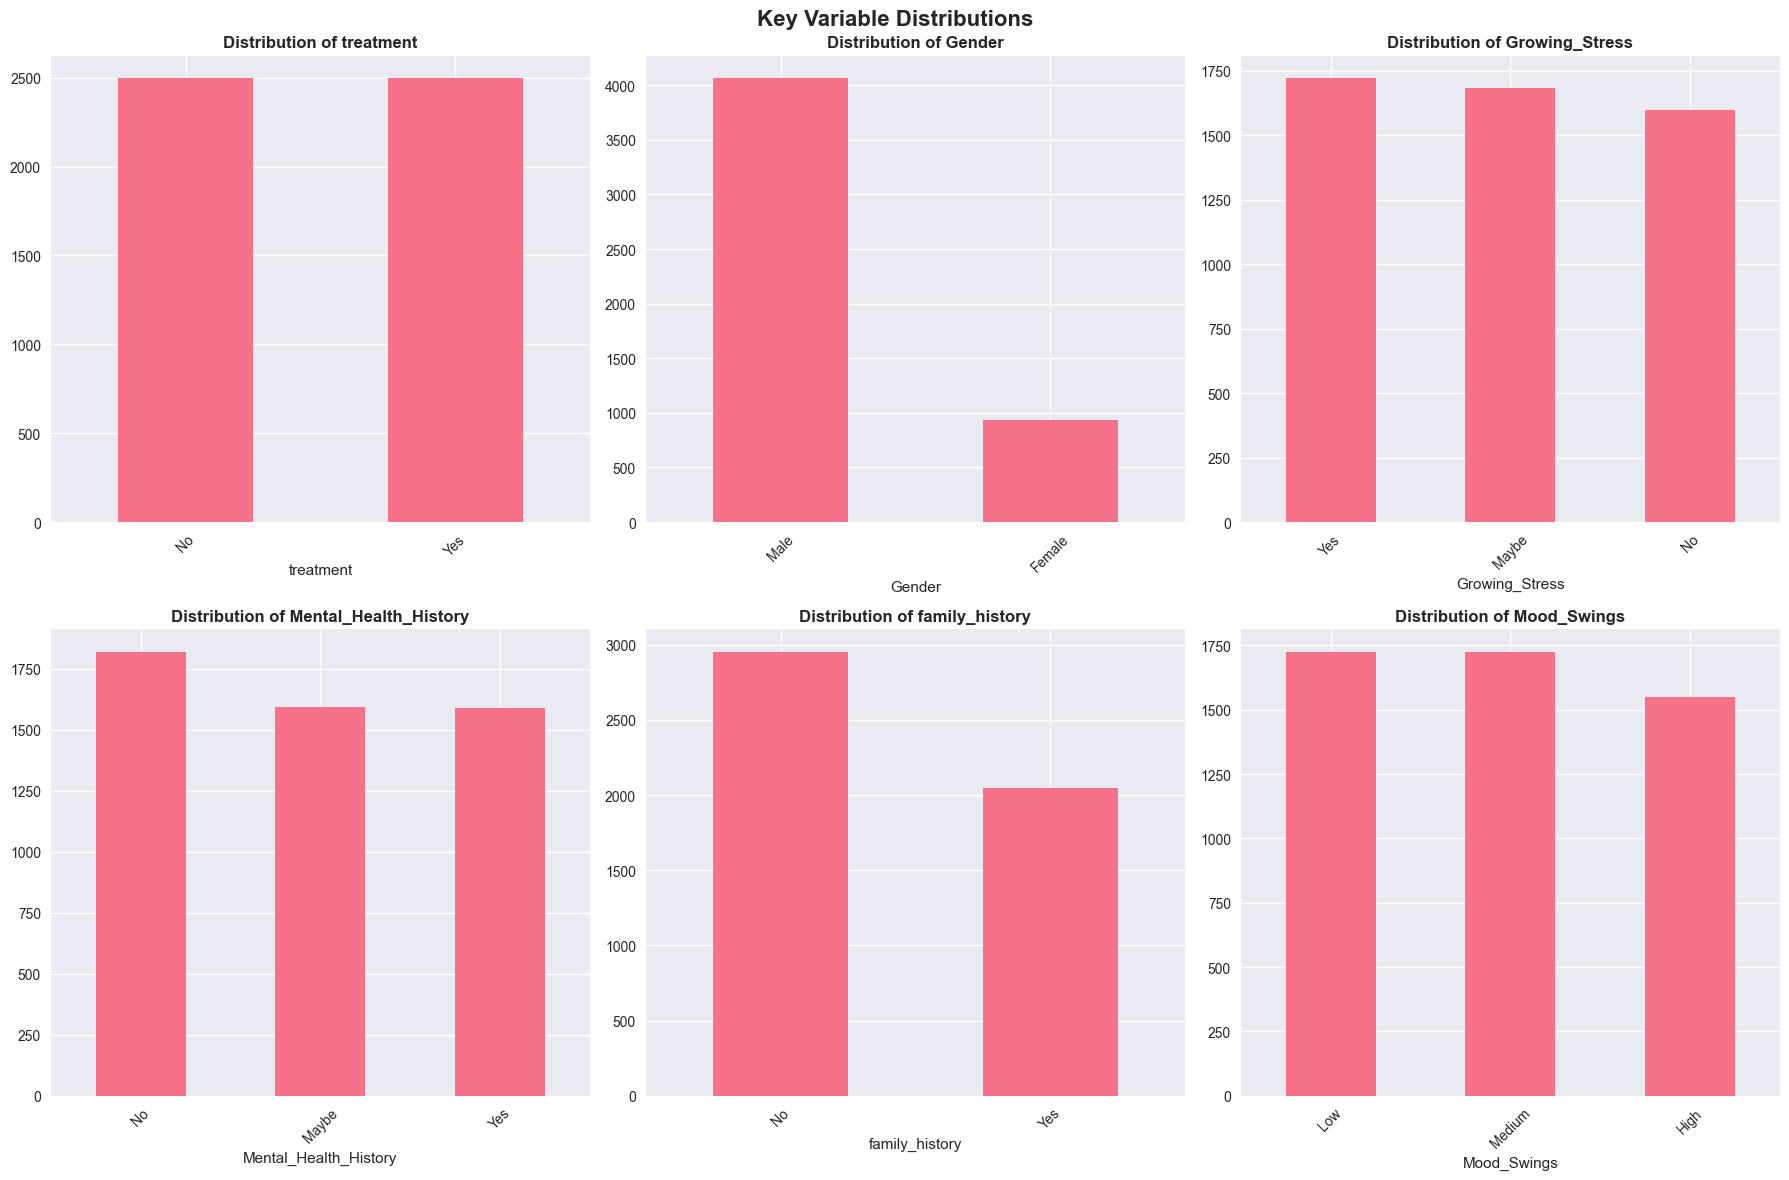

In [7]:
# Quick Data Visualization - Optimized for large datasets
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Key Variable Distributions', fontsize=16, fontweight='bold')

# Sample data for faster plotting if dataset is very large
plot_sample = df.sample(n=min(5000, len(df)), random_state=42) if len(df) > 5000 else df

# Key categorical variables
key_cols = ['treatment', 'Gender', 'Growing_Stress', 'Mental_Health_History', 'family_history', 'Mood_Swings']

for i, col in enumerate(key_cols):
    row = i // 3
    col_idx = i % 3
    
    plot_sample[col].value_counts().plot(kind='bar', ax=axes[row, col_idx], rot=45)
    axes[row, col_idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[row, col_idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

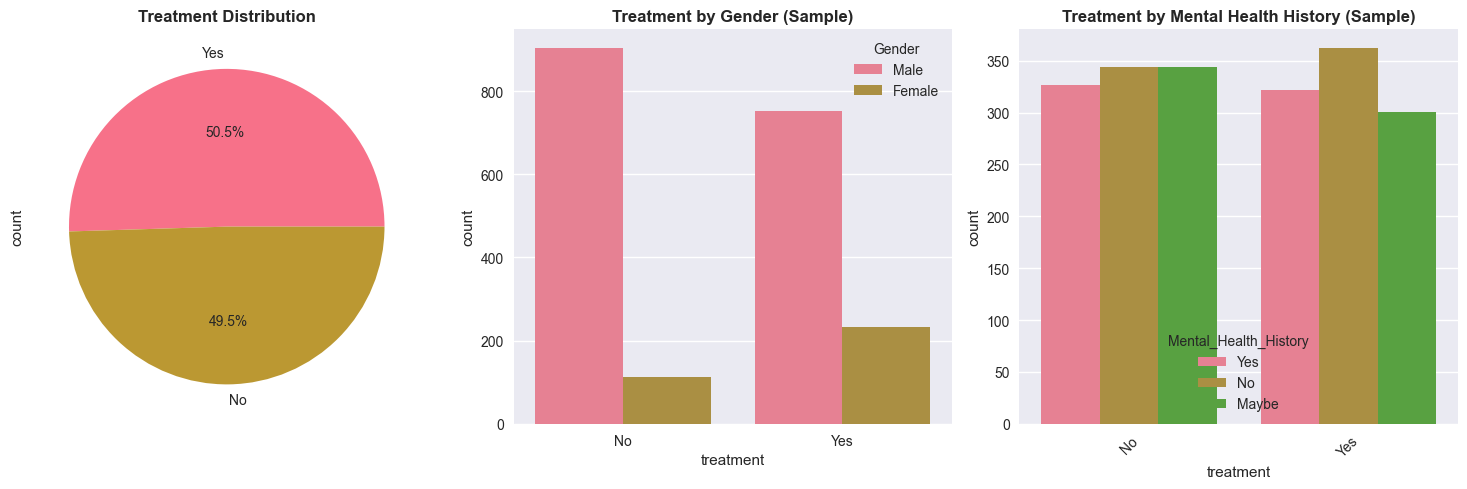

In [8]:
# Target variable analysis
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['treatment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Treatment Distribution', fontweight='bold')

plt.subplot(1, 3, 2)
# Use sample for faster plotting
sample_df = df.sample(n=min(2000, len(df)), random_state=42)
sns.countplot(data=sample_df, x='treatment', hue='Gender')
plt.title('Treatment by Gender (Sample)', fontweight='bold')

plt.subplot(1, 3, 3)
sns.countplot(data=sample_df, x='treatment', hue='Mental_Health_History')
plt.title('Treatment by Mental Health History (Sample)', fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# Data Preprocessing - Optimized for speed
print("Starting data preprocessing...")
start_time = time.time()

# Create a copy for preprocessing
df_encoded = df.copy()

# Remove timestamp column
if 'Timestamp' in df_encoded.columns:
    df_encoded = df_encoded.drop(['Timestamp'], axis=1)

# Handle missing values efficiently
df_encoded = df_encoded.fillna('Unknown')

# Fast label encoding for all categorical variables
label_encoders = {}
for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        le = LabelEncoder()
        df_encoded[column] = le.fit_transform(df_encoded[column].astype(str))
        label_encoders[column] = le

preprocessing_time = time.time() - start_time
print(f"Preprocessing completed in {preprocessing_time:.2f} seconds")
print("Encoded dataset shape:", df_encoded.shape)
print("\nEncoded dataset sample:")
df_encoded.head()

Starting data preprocessing...
Preprocessing completed in 0.81 seconds
Encoded dataset shape: (292364, 16)

Encoded dataset sample:


,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,34,1,1,0,1,0,2,1,2,2,0,1,2,1,1
1,0,34,1,1,1,1,0,2,1,2,2,0,1,2,1,0
2,0,34,1,1,1,1,0,2,1,2,2,0,1,2,1,2
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2


Computing correlation matrix...


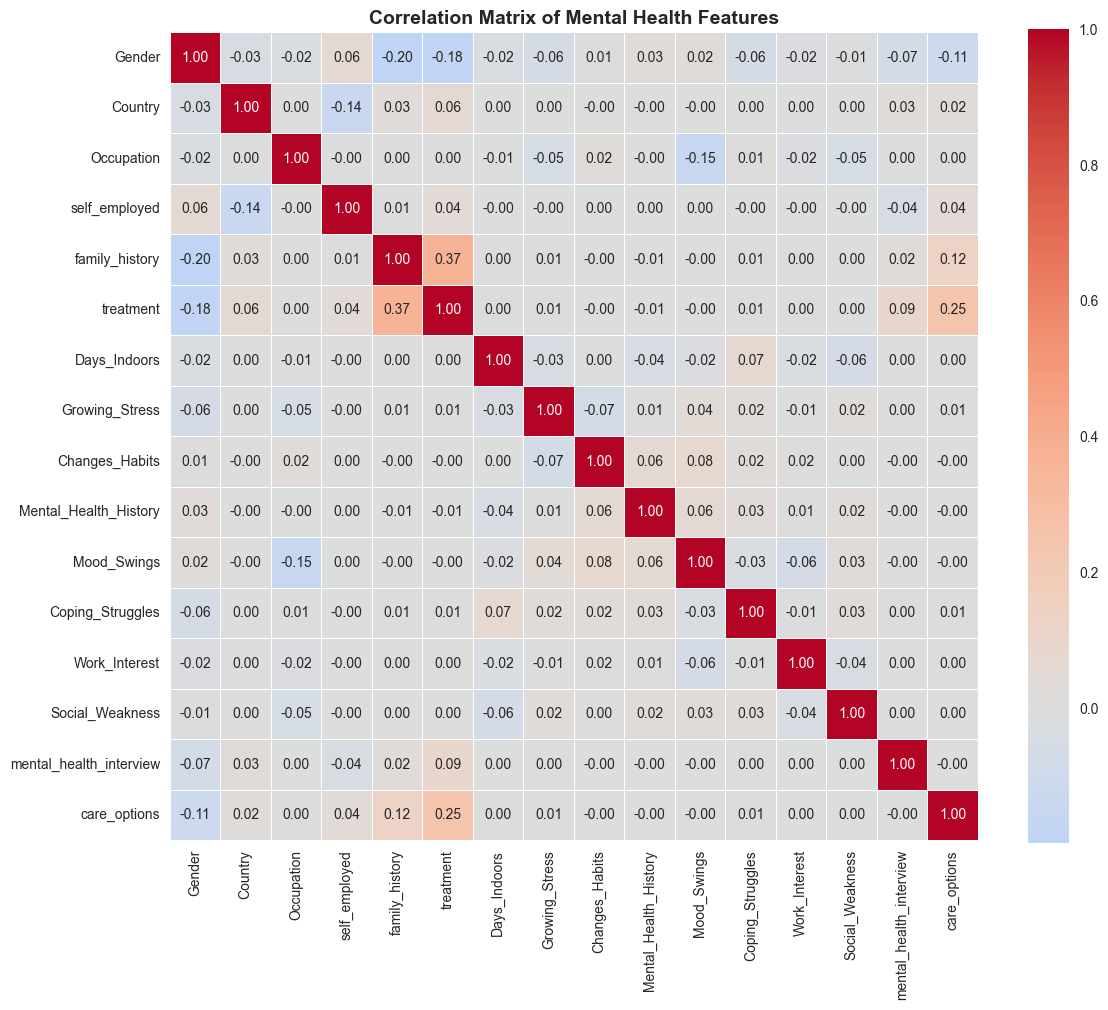


Correlation with Treatment (Target Variable):
treatment                  1.000000
family_history             0.366781
care_options               0.253428
Gender                     0.177203
mental_health_interview    0.092041
Country                    0.062334
self_employed              0.038028
Growing_Stress             0.010056
Coping_Struggles           0.009985
Mental_Health_History      0.005099
Occupation                 0.004121
Days_Indoors               0.003891
Mood_Swings                0.003828
Work_Interest              0.003483
Social_Weakness            0.001521
Changes_Habits             0.000986
Name: treatment, dtype: float64


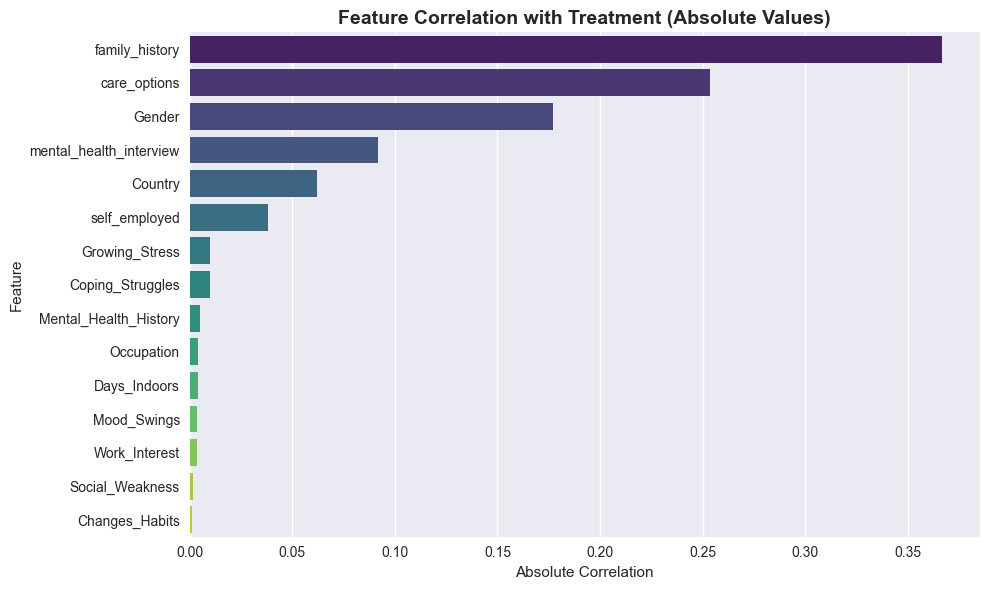

In [10]:
# Correlation Analysis - Optimized
print("Computing correlation matrix...")
correlation_matrix = df_encoded.corr()

# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Mental Health Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlation with target variable
print("\nCorrelation with Treatment (Target Variable):")
target_corr = correlation_matrix['treatment'].abs().sort_values(ascending=False)
print(target_corr)

# Feature importance visualization
plt.figure(figsize=(10, 6))
target_corr_df = target_corr[1:].to_frame().reset_index()  # Exclude self-correlation
target_corr_df.columns = ['Feature', 'Correlation']

sns.barplot(data=target_corr_df, x='Correlation', y='Feature', palette='viridis')
plt.title('Feature Correlation with Treatment (Absolute Values)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

In [11]:
# Prepare data for machine learning
X = df_encoded.drop('treatment', axis=1)
y = df_encoded['treatment']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print(f"Class balance: {y.value_counts(normalize=True)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Testing set: {X_test.shape[0]:,} samples")

# Scale features for algorithms that require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature matrix shape: (292364, 15)
Target vector shape: (292364,)

Target distribution:
treatment
1    147606
0    144758
Name: count, dtype: int64
Class balance: treatment
1    0.504871
0    0.495129
Name: proportion, dtype: float64

Training set: 233,891 samples
Testing set: 58,473 samples
Feature scaling completed!


In [12]:
# Define FAST algorithms only - Optimized for 30K+ datasets
algorithms = {
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=42),  # Faster than RF
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'Linear SVM': LinearSVC(random_state=42, max_iter=1000, dual=False),  # Fast linear SVM
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42)  # Reduced estimators for speed
}

print(f"Fast algorithms selected: {len(algorithms)}")
print("Algorithms optimized for large datasets:")
for name in algorithms.keys():
    print(f"✓ {name}")
print("\nSlow algorithms excluded: SVM (RBF), Neural Networks")

Fast algorithms selected: 9
Algorithms optimized for large datasets:
✓ Random Forest
✓ Extra Trees
✓ Logistic Regression
✓ Linear SVM
✓ Gradient Boosting
✓ Naive Bayes
✓ KNN
✓ Decision Tree
✓ AdaBoost

Slow algorithms excluded: SVM (RBF), Neural Networks


In [13]:
# Train and evaluate all algorithms - WITH TIMING
results = {}
cv_results = {}
training_times = {}

print("Starting algorithm training and comparison...")
print("=" * 60)

for name, algorithm in algorithms.items():
    print(f"Training {name}...", end=" ")
    start_time = time.time()
    
    try:
        # Use scaled data for algorithms that benefit from it
        if name in ['Logistic Regression', 'Linear SVM', 'KNN']:
            algorithm.fit(X_train_scaled, y_train)
            y_pred = algorithm.predict(X_test_scaled)
            # Reduced CV folds for speed on large dataset
            cv_scores = cross_val_score(algorithm, X_train_scaled, y_train, cv=3, n_jobs=-1)
        else:
            algorithm.fit(X_train, y_train)
            y_pred = algorithm.predict(X_test)
            cv_scores = cross_val_score(algorithm, X_train, y_train, cv=3, n_jobs=-1)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        training_time = time.time() - start_time
        training_times[name] = training_time
        
        results[name] = {
            'model': algorithm,
            'accuracy': accuracy,
            'f1_score': f1,
            'predictions': y_pred
        }
        
        cv_results[name] = {
            'mean_cv_score': cv_scores.mean(),
            'std_cv_score': cv_scores.std()
        }
        
        print(f"[{training_time:.1f}s]")
        print(f"    Accuracy: {accuracy:.4f} | F1: {f1:.4f} | CV: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
        
    except Exception as e:
        print(f"FAILED: {str(e)}")
        continue

total_time = sum(training_times.values())
print("=" * 60)
print(f"All algorithms completed in {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print("\nTraining times:")
for name, t in sorted(training_times.items(), key=lambda x: x[1]):
    print(f"  {name:<18}: {t:.2f}s")

Starting algorithm training and comparison...
Training Random Forest... [36.6s]
    Accuracy: 0.7368 | F1: 0.7364 | CV: 0.7381 (+/- 0.0012)
Training Extra Trees... [38.9s]
    Accuracy: 0.7216 | F1: 0.7215 | CV: 0.7193 (+/- 0.0006)
Training Logistic Regression... [3.3s]
    Accuracy: 0.7032 | F1: 0.7031 | CV: 0.7036 (+/- 0.0021)
Training Linear SVM... [1.2s]
    Accuracy: 0.7023 | F1: 0.7022 | CV: 0.7003 (+/- 0.0097)
Training Gradient Boosting... [44.1s]
    Accuracy: 0.7446 | F1: 0.7445 | CV: 0.7426 (+/- 0.0037)
Training Naive Bayes... [0.6s]
    Accuracy: 0.6684 | F1: 0.6678 | CV: 0.6714 (+/- 0.0017)
Training KNN... [116.2s]
    Accuracy: 0.6601 | F1: 0.6600 | CV: 0.6619 (+/- 0.0020)
Training Decision Tree... [2.5s]
    Accuracy: 0.7360 | F1: 0.7359 | CV: 0.7370 (+/- 0.0009)
Training AdaBoost... [14.1s]
    Accuracy: 0.7020 | F1: 0.7019 | CV: 0.7037 (+/- 0.0007)
All algorithms completed in 257.4 seconds (4.3 minutes)

Training times:
  Naive Bayes       : 0.57s
  Linear SVM        : 

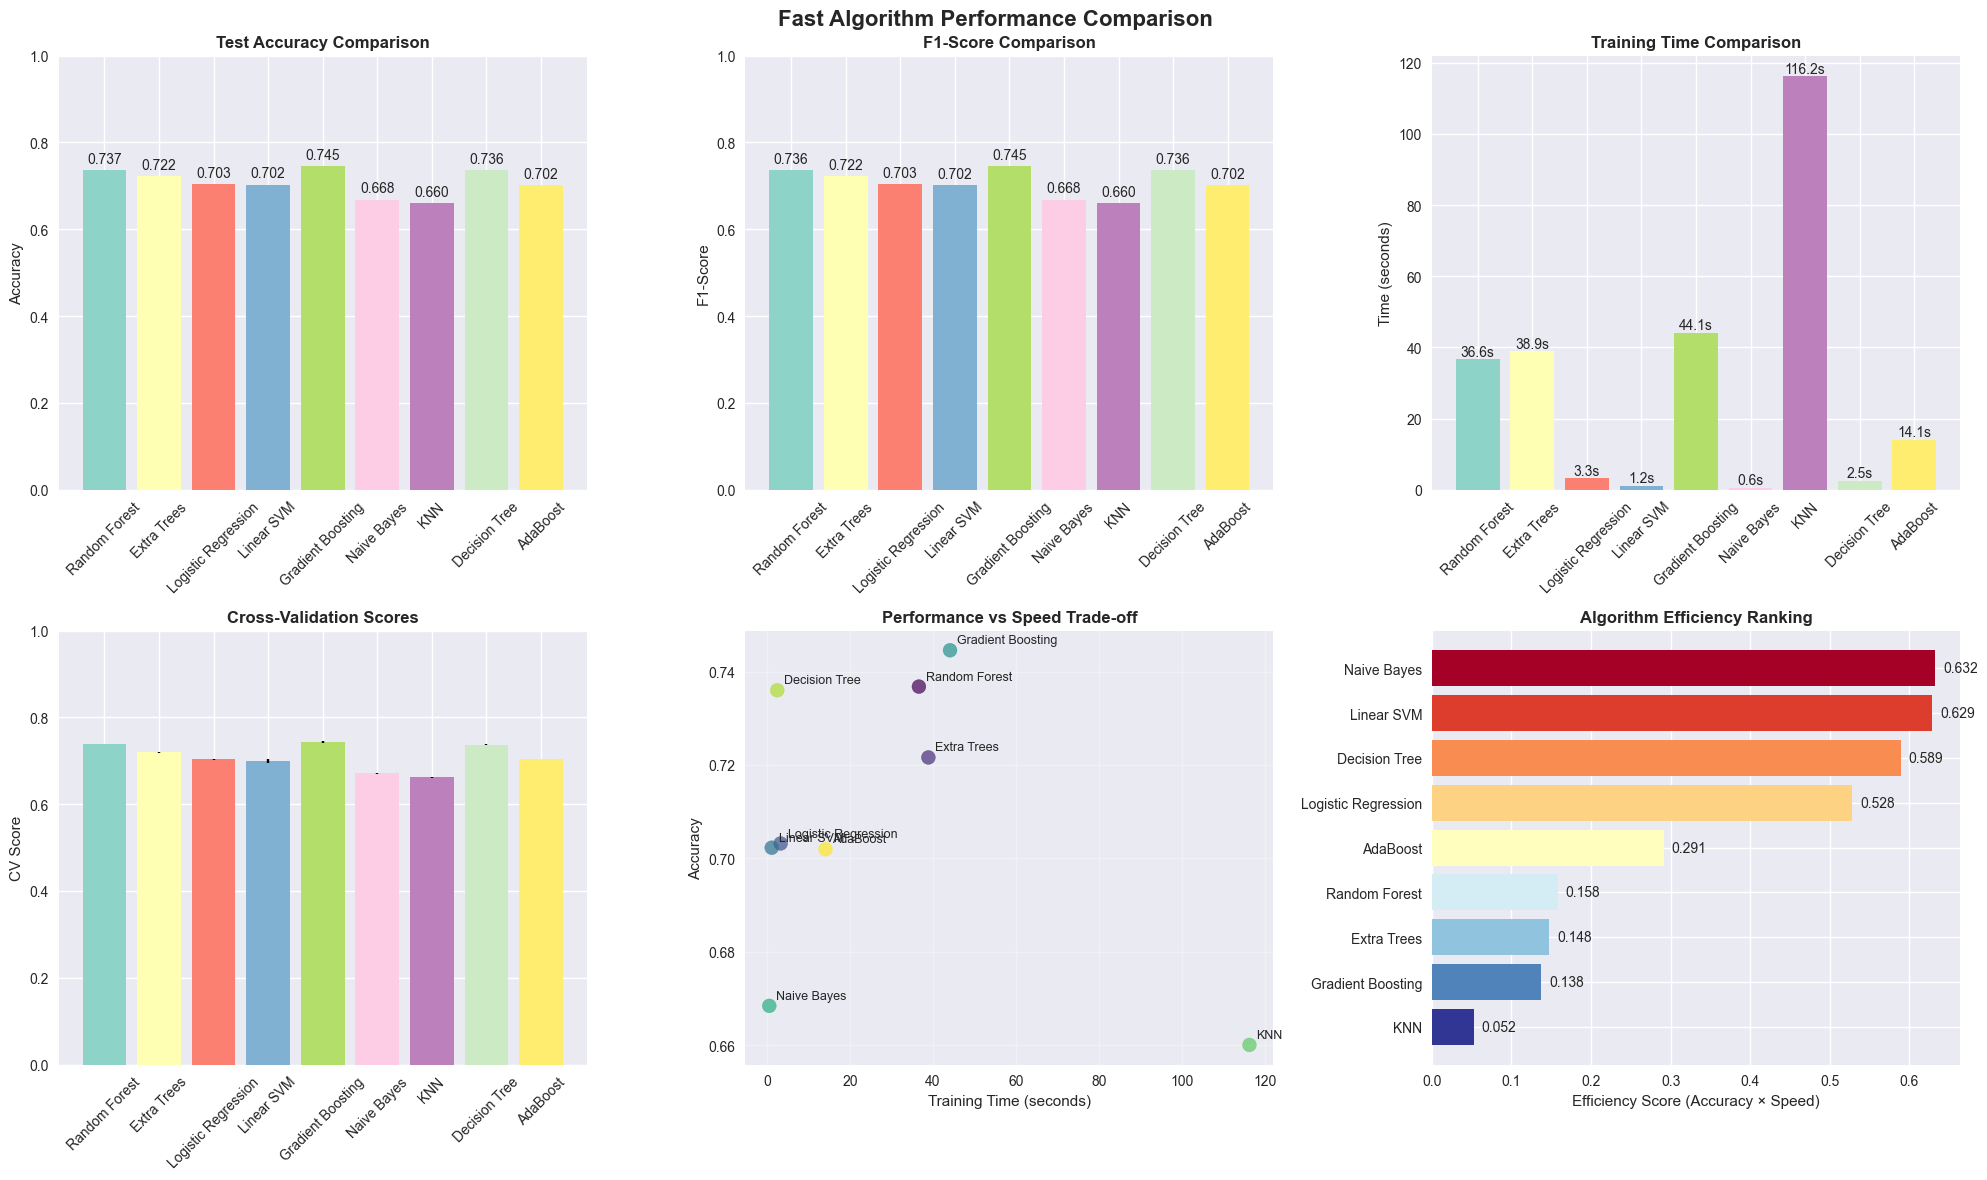

In [14]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Fast Algorithm Performance Comparison', fontsize=16, fontweight='bold')

algorithm_names = list(results.keys())
colors = plt.cm.Set3(np.linspace(0, 1, len(algorithm_names)))

# 1. Accuracy comparison
accuracies = [results[name]['accuracy'] for name in algorithm_names]
bars1 = axes[0,0].bar(algorithm_names, accuracies, color=colors)
axes[0,0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylim(0, 1)

# Add accuracy values on bars
for bar, acc in zip(bars1, accuracies):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{acc:.3f}', ha='center', va='bottom')

# 2. F1-Score comparison
f1_scores = [results[name]['f1_score'] for name in algorithm_names]
bars2 = axes[0,1].bar(algorithm_names, f1_scores, color=colors)
axes[0,1].set_title('F1-Score Comparison', fontweight='bold')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_ylim(0, 1)

for bar, f1 in zip(bars2, f1_scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{f1:.3f}', ha='center', va='bottom')

# 3. Training time comparison
times = [training_times[name] for name in algorithm_names]
bars3 = axes[0,2].bar(algorithm_names, times, color=colors)
axes[0,2].set_title('Training Time Comparison', fontweight='bold')
axes[0,2].set_ylabel('Time (seconds)')
axes[0,2].tick_params(axis='x', rotation=45)

for bar, t in zip(bars3, times):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                   f'{t:.1f}s', ha='center', va='bottom')

# 4. Cross-validation scores
cv_means = [cv_results[name]['mean_cv_score'] for name in algorithm_names]
cv_stds = [cv_results[name]['std_cv_score'] for name in algorithm_names]
bars4 = axes[1,0].bar(algorithm_names, cv_means, yerr=cv_stds, capsize=5, color=colors)
axes[1,0].set_title('Cross-Validation Scores', fontweight='bold')
axes[1,0].set_ylabel('CV Score')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylim(0, 1)

# 5. Performance vs Speed scatter plot
axes[1,1].scatter(times, accuracies, s=100, c=range(len(algorithm_names)), cmap='viridis', alpha=0.7)
for i, name in enumerate(algorithm_names):
    axes[1,1].annotate(name, (times[i], accuracies[i]), xytext=(5, 5), 
                       textcoords='offset points', fontsize=9)
axes[1,1].set_xlabel('Training Time (seconds)')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title('Performance vs Speed Trade-off', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

# 6. Algorithm ranking
efficiency_score = []
for name in algorithm_names:
    acc = results[name]['accuracy']
    time_penalty = 1 / (1 + training_times[name]/10)  # Penalize slow algorithms
    score = acc * time_penalty
    efficiency_score.append(score)

ranking_df = pd.DataFrame({
    'Algorithm': algorithm_names,
    'Efficiency_Score': efficiency_score
}).sort_values('Efficiency_Score', ascending=True)

bars6 = axes[1,2].barh(range(len(ranking_df)), ranking_df['Efficiency_Score'], 
                       color=plt.cm.RdYlBu_r(np.linspace(0, 1, len(ranking_df))))
axes[1,2].set_yticks(range(len(ranking_df)))
axes[1,2].set_yticklabels(ranking_df['Algorithm'])
axes[1,2].set_xlabel('Efficiency Score (Accuracy × Speed)')
axes[1,2].set_title('Algorithm Efficiency Ranking', fontweight='bold')

for bar, score in zip(bars6, ranking_df['Efficiency_Score']):
    axes[1,2].text(score + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{score:.3f}', va='center', ha='left')

plt.tight_layout()
plt.show()

In [15]:
# Find the best performing algorithm
best_algorithm_name = max(results.keys(), key=lambda x: results[x]['accuracy'])
best_model = results[best_algorithm_name]['model']

print("=" * 50)
print("BEST PERFORMING ALGORITHM")
print("=" * 50)
print(f"🏆 Algorithm: {best_algorithm_name}")
print(f"📊 Accuracy: {results[best_algorithm_name]['accuracy']:.4f} ({results[best_algorithm_name]['accuracy']*100:.2f}%)")
print(f"🎯 F1-Score: {results[best_algorithm_name]['f1_score']:.4f}")
print(f"📈 CV Score: {cv_results[best_algorithm_name]['mean_cv_score']:.4f} (+/- {cv_results[best_algorithm_name]['std_cv_score']:.4f})")
print(f"⏱️ Training Time: {training_times[best_algorithm_name]:.2f} seconds")
print("=" * 50)

BEST PERFORMING ALGORITHM
🏆 Algorithm: Gradient Boosting
📊 Accuracy: 0.7446 (74.46%)
🎯 F1-Score: 0.7445
📈 CV Score: 0.7426 (+/- 0.0018)
⏱️ Training Time: 44.09 seconds


Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74     28952
           1       0.74      0.76      0.75     29521

    accuracy                           0.74     58473
   macro avg       0.74      0.74      0.74     58473
weighted avg       0.74      0.74      0.74     58473



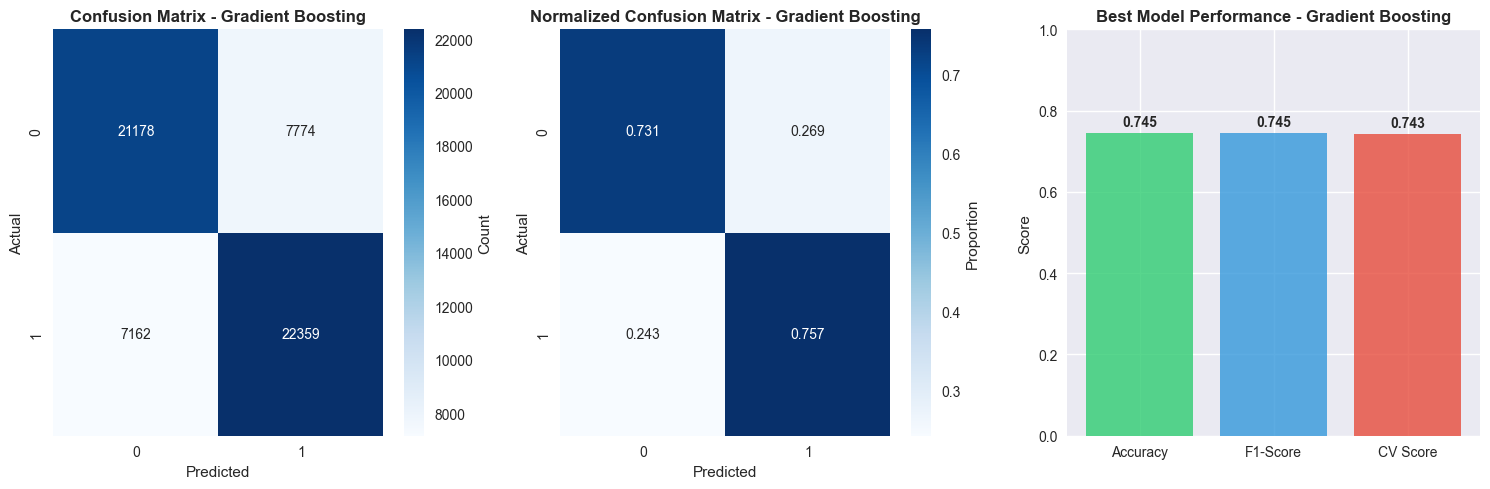

In [16]:
# Detailed analysis of the best model
best_predictions = results[best_algorithm_name]['predictions']

print("Classification Report for Best Model:")
print("=" * 40)
print(classification_report(y_test, best_predictions))

# Confusion Matrix Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_algorithm_name}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Normalized Confusion Matrix
plt.subplot(1, 3, 2)
cm_normalized = confusion_matrix(y_test, best_predictions, normalize='true')
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', cbar_kws={'label': 'Proportion'})
plt.title(f'Normalized Confusion Matrix - {best_algorithm_name}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Performance metrics visualization
plt.subplot(1, 3, 3)
metrics = ['Accuracy', 'F1-Score', 'CV Score']
values = [results[best_algorithm_name]['accuracy'], 
          results[best_algorithm_name]['f1_score'],
          cv_results[best_algorithm_name]['mean_cv_score']]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = plt.bar(metrics, values, color=colors, alpha=0.8)
plt.title(f'Best Model Performance - {best_algorithm_name}', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

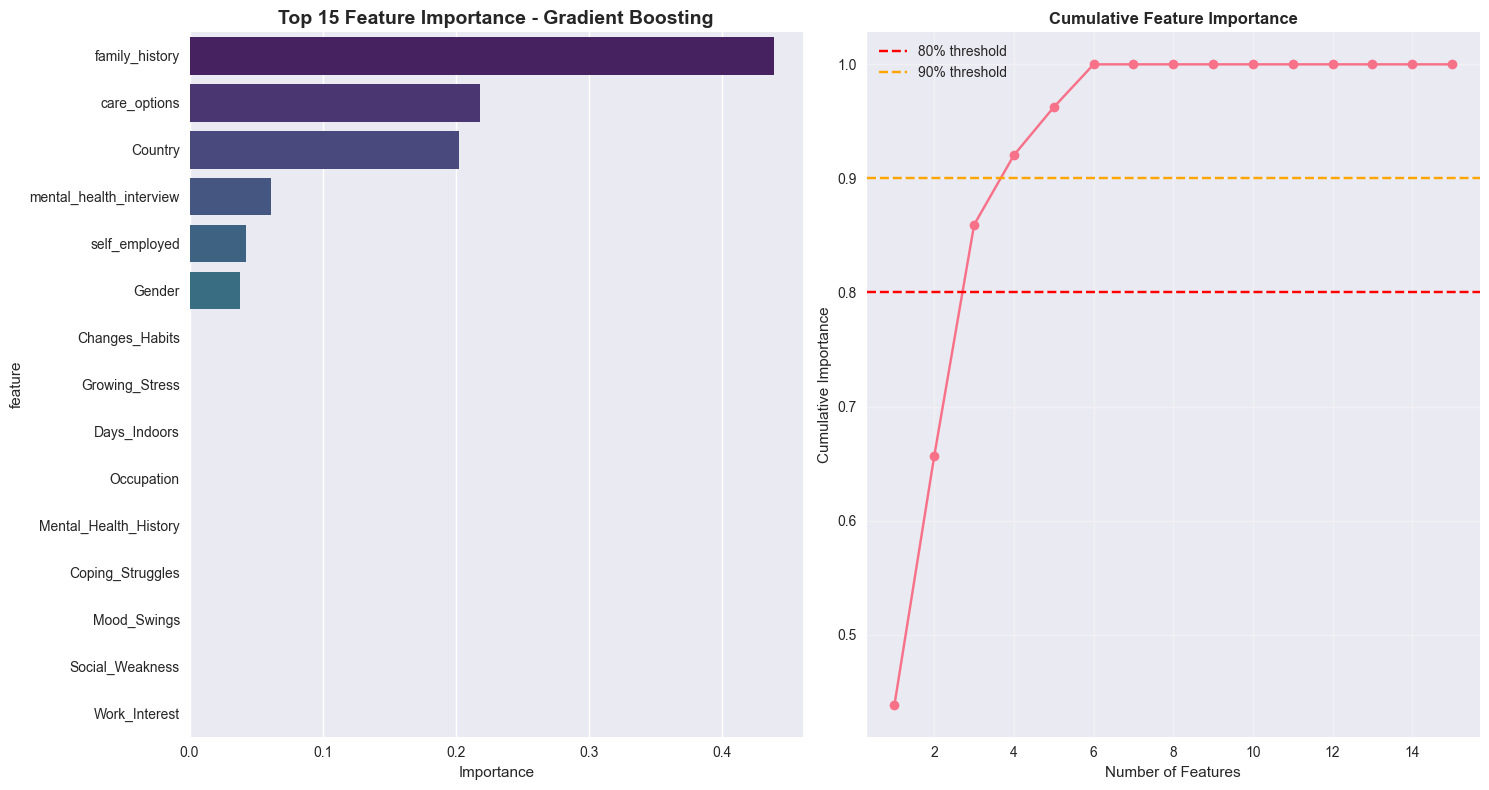

Top 10 Most Important Features:
                    feature    importance
4            family_history  4.386168e-01
14             care_options  2.184199e-01
1                   Country  2.023883e-01
13  mental_health_interview  6.102505e-02
3             self_employed  4.202522e-02
0                    Gender  3.752484e-02
7            Changes_Habits  5.751416e-16
6            Growing_Stress  0.000000e+00
5              Days_Indoors  0.000000e+00
2                Occupation  0.000000e+00

📊 Features needed for 90% importance: 14 out of 15


In [17]:
# Feature importance analysis for tree-based models
if best_algorithm_name in ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'Decision Tree', 'AdaBoost']:
    feature_importance = best_model.feature_importances_
    feature_names = X.columns
    
    # Create feature importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    # Visualize feature importance
    plt.figure(figsize=(15, 8))
    
    plt.subplot(1, 2, 1)
    top_features = importance_df.head(15)  # Top 15 features
    sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
    plt.title(f'Top 15 Feature Importance - {best_algorithm_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    
    plt.subplot(1, 2, 2)
    # Cumulative importance
    cumsum = importance_df['importance'].cumsum()
    plt.plot(range(1, len(cumsum)+1), cumsum, marker='o')
    plt.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
    plt.axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')
    plt.xlabel('Number of Features')
    plt.ylabel('Cumulative Importance')
    plt.title('Cumulative Feature Importance', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features:")
    print(importance_df.head(10))
    
    # Find minimum features for 90% importance
    features_90 = (cumsum >= 0.9).idxmax() + 1
    print(f"\n📊 Features needed for 90% importance: {features_90} out of {len(feature_names)}")
else:
    print(f"{best_algorithm_name} doesn't provide feature importance scores.")
    
    # For linear models, show coefficient analysis
    if best_algorithm_name in ['Logistic Regression', 'Linear SVM']:
        if hasattr(best_model, 'coef_'):
            coef_df = pd.DataFrame({
                'feature': X.columns,
                'coefficient': abs(best_model.coef_[0])
            }).sort_values('coefficient', ascending=False)
            
            plt.figure(figsize=(12, 8))
            sns.barplot(data=coef_df.head(15), y='feature', x='coefficient', palette='plasma')
            plt.title(f'Top 15 Feature Coefficients - {best_algorithm_name}', fontsize=14, fontweight='bold')
            plt.xlabel('Absolute Coefficient Value')
            plt.tight_layout()
            plt.show()
            
            print("Top 10 Feature Coefficients:")
            print(coef_df.head(10))

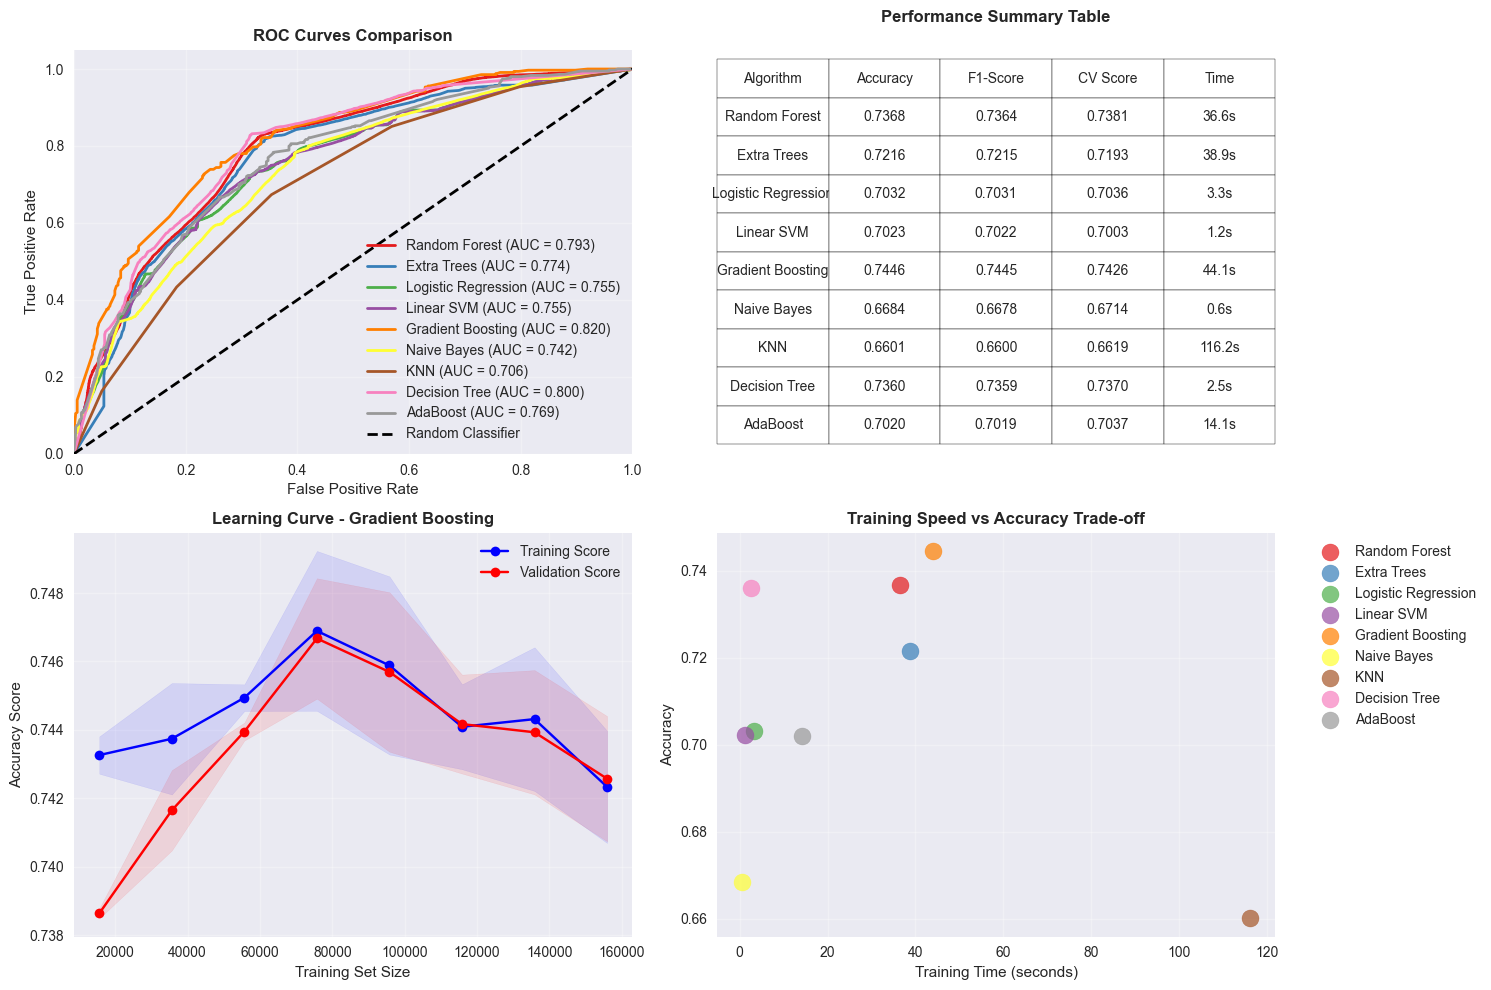

In [18]:
# ROC Curve Analysis for models that support probability prediction
plt.figure(figsize=(15, 10))

# Plot ROC curves for multiple algorithms
plt.subplot(2, 2, 1)
colors = plt.cm.Set1(np.linspace(0, 1, len(algorithms)))
roc_scores = {}

for i, (name, algorithm) in enumerate(results.items()):
    try:
        if hasattr(algorithm['model'], 'predict_proba'):
            if name in ['Logistic Regression', 'Linear SVM', 'KNN']:
                y_proba = algorithm['model'].predict_proba(X_test_scaled)[:, 1]
            else:
                y_proba = algorithm['model'].predict_proba(X_test)[:, 1]
        elif hasattr(algorithm['model'], 'decision_function'):
            if name in ['Logistic Regression', 'Linear SVM', 'KNN']:
                y_proba = algorithm['model'].decision_function(X_test_scaled)
            else:
                y_proba = algorithm['model'].decision_function(X_test)
        else:
            continue
            
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        roc_scores[name] = roc_auc
        
        plt.plot(fpr, tpr, color=colors[i], lw=2, 
                label=f'{name} (AUC = {roc_auc:.3f})')
    except Exception as e:
        print(f"Could not plot ROC for {name}: {e}")
        continue

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Performance summary table
plt.subplot(2, 2, 2)
plt.axis('tight')
plt.axis('off')

summary_data = []
for name in algorithm_names:
    summary_data.append([
        name,
        f"{results[name]['accuracy']:.4f}",
        f"{results[name]['f1_score']:.4f}",
        f"{cv_results[name]['mean_cv_score']:.4f}",
        f"{training_times[name]:.1f}s"
    ])

table = plt.table(cellText=summary_data,
                 colLabels=['Algorithm', 'Accuracy', 'F1-Score', 'CV Score', 'Time'],
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
plt.title('Performance Summary Table', fontweight='bold', pad=20)

# Learning curve for the best model
plt.subplot(2, 2, 3)
from sklearn.model_selection import learning_curve

# Use smaller train sizes for speed on large dataset
train_sizes_range = np.linspace(0.1, 1.0, 8)
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=3, n_jobs=-1, 
    train_sizes=train_sizes_range, random_state=42)

plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', 
         color='blue', label='Training Score')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', 
         color='red', label='Validation Score')
plt.fill_between(train_sizes, np.mean(train_scores, axis=1) - np.std(train_scores, axis=1),
                 np.mean(train_scores, axis=1) + np.std(train_scores, axis=1), alpha=0.1, color='blue')
plt.fill_between(train_sizes, np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                 np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.1, color='red')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title(f'Learning Curve - {best_algorithm_name}', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Speed vs Accuracy scatter
plt.subplot(2, 2, 4)
for i, name in enumerate(algorithm_names):
    plt.scatter(training_times[name], results[name]['accuracy'], 
               s=150, alpha=0.7, label=name, color=colors[i])

plt.xlabel('Training Time (seconds)')
plt.ylabel('Accuracy')
plt.title('Training Speed vs Accuracy Trade-off', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [19]:
# Quick hyperparameter tuning for the best model
print(f"Performing quick hyperparameter tuning for {best_algorithm_name}...")

tuning_start = time.time()

if best_algorithm_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
elif best_algorithm_name == 'Extra Trees':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
elif best_algorithm_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    }
elif best_algorithm_name == 'Linear SVM':
    param_grid = {
        'C': [0.1, 1, 10],
        'loss': ['hinge', 'squared_hinge']
    }
elif best_algorithm_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5]
    }
else:
    param_grid = {}

if param_grid:
    # Create new instance of the best algorithm
    best_algorithm_class = type(best_model)
    
    # Only pass n_jobs if the model supports it (exclude Gradient Boosting, Logistic Regression, etc.)
    valid_params = {'random_state': 42}
    if hasattr(best_model, 'n_jobs') and best_algorithm_name in ['Random Forest', 'Extra Trees']:
        valid_params['n_jobs'] = -1

    tuning_model = best_algorithm_class(**valid_params)
    
    # Quick grid search with reduced CV
    grid_search = GridSearchCV(tuning_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    
    # Use scaled features for linear models, raw for others
    if best_algorithm_name in ['Logistic Regression', 'Linear SVM']:
        grid_search.fit(X_train_scaled, y_train)
        tuned_predictions = grid_search.predict(X_test_scaled)
    else:
        grid_search.fit(X_train, y_train)
        tuned_predictions = grid_search.predict(X_test)
    
    tuned_accuracy = accuracy_score(y_test, tuned_predictions)
    tuning_time = time.time() - tuning_start
    
    print(f"\n✅ Hyperparameter tuning completed in {tuning_time:.1f} seconds")
    print(f"🎯 Best parameters: {grid_search.best_params_}")
    print(f"📊 Original accuracy: {results[best_algorithm_name]['accuracy']:.4f}")
    print(f"📈 Tuned accuracy: {tuned_accuracy:.4f}")
    print(f"🚀 Improvement: {tuned_accuracy - results[best_algorithm_name]['accuracy']:.4f}")
    
    # Save the best tuned model
    final_model = grid_search.best_estimator_
    final_accuracy = tuned_accuracy
else:
    print(f"No hyperparameter tuning defined for {best_algorithm_name}")
    final_model = best_model
    final_accuracy = results[best_algorithm_name]['accuracy']

Performing quick hyperparameter tuning for Gradient Boosting...

✅ Hyperparameter tuning completed in 1077.2 seconds
🎯 Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
📊 Original accuracy: 0.7446
📈 Tuned accuracy: 0.7851
🚀 Improvement: 0.0405


In [20]:
# Model Deployment Preparation
import joblib
import pickle
import os

print("Preparing model for deployment...")

# Save the final model and preprocessing components
model_components = {
    'model': final_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': X.columns.tolist(),
    'model_name': best_algorithm_name,
    'accuracy': final_accuracy,
    'training_samples': X_train.shape[0],
    'features_count': X.shape[1],
    'training_time': training_times[best_algorithm_name]
}

# Save using joblib
joblib.dump(model_components, 'mental_health_prediction_model.pkl')

print("\n✅ Model saved as 'mental_health_prediction_model.pkl'")
print(f"\n📋 FINAL MODEL SUMMARY:")
print(f"🏆 Algorithm: {best_algorithm_name}")
print(f"🎯 Final Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"📊 Features used: {len(X.columns)}")
print(f"🔢 Training samples: {X_train.shape[0]:,}")
print(f"🧪 Testing samples: {X_test.shape[0]:,}")
print(f"⏱️ Training time: {training_times[best_algorithm_name]:.2f} seconds")
print(f"💾 Model size: {os.path.getsize('mental_health_prediction_model.pkl')/1024/1024:.2f} MB")

Preparing model for deployment...

✅ Model saved as 'mental_health_prediction_model.pkl'

📋 FINAL MODEL SUMMARY:
🏆 Algorithm: Gradient Boosting
🎯 Final Accuracy: 0.7851 (78.51%)
📊 Features used: 15
🔢 Training samples: 233,891
🧪 Testing samples: 58,473
⏱️ Training time: 44.09 seconds
💾 Model size: 0.66 MB


In [21]:
# Enhanced prediction function for new data
def predict_mental_health_treatment(new_data_dict):
    """
    Predict mental health treatment need for new data
    Optimized for production use
    
    Parameters:
    new_data_dict: Dictionary with feature values
    
    Returns:
    Dictionary with prediction, probability, and confidence
    """
    try:
        # Load the saved model
        model_components = joblib.load('mental_health_prediction_model.pkl')
        model = model_components['model']
        scaler = model_components['scaler']
        label_encoders = model_components['label_encoders']
        feature_columns = model_components['feature_columns']
        model_name = model_components['model_name']
        
        # Create DataFrame from input
        new_df = pd.DataFrame([new_data_dict])
        
        # Apply same preprocessing as training data
        for column in feature_columns:
            if column in new_df.columns and column in label_encoders:
                value = new_df[column].iloc[0]
                if value in label_encoders[column].classes_:
                    new_df[column] = label_encoders[column].transform([value])
                else:
                    # Handle unseen categories
                    new_df[column] = 0  # Default to first class
            elif column not in new_df.columns:
                new_df[column] = 0  # Default value for missing features
        
        # Ensure correct column order
        new_df = new_df[feature_columns]
        
        # Scale if needed
        if model_name in ['Logistic Regression', 'Linear SVM', 'KNN']:
            new_df_processed = scaler.transform(new_df)
        else:
            new_df_processed = new_df
        
        # Make prediction
        prediction = int(model.predict(new_df_processed)[0])
        
        # Get probability if available
        if hasattr(model, 'predict_proba'):
            probabilities = model.predict_proba(new_df_processed)[0]
            confidence = float(max(probabilities))
            prob_no = float(probabilities[0])
            prob_yes = float(probabilities[1])
        elif hasattr(model, 'decision_function'):
            decision_score = model.decision_function(new_df_processed)[0]
            confidence = abs(float(decision_score))
            prob_no = 0.5
            prob_yes = 0.5
        else:
            confidence = 0.8  # Default confidence
            prob_no = 0.5
            prob_yes = 0.5
        
        # Decode prediction
        treatment_need = "Yes" if prediction == 1 else "No"
        
        return {
            'treatment_recommended': treatment_need,
            'confidence': confidence,
            'probability_no_treatment': prob_no,
            'probability_treatment': prob_yes,
            'model_used': model_name,
            'prediction_successful': True
        }
    
    except Exception as e:
        return {
            'treatment_recommended': 'Error',
            'confidence': 0.0,
            'error_message': str(e),
            'prediction_successful': False
        }

# Test the prediction function
sample_data = {
    'Gender': 'Female',
    'Country': 'United States',
    'Occupation': 'Corporate',
    'self_employed': 'No',
    'family_history': 'Yes',
    'Days_Indoors': '1-14 days',
    'Growing_Stress': 'Yes',
    'Changes_Habits': 'No',
    'Mental_Health_History': 'Yes',
    'Mood_Swings': 'Medium',
    'Coping_Struggles': 'No',
    'Work_Interest': 'No',
    'Social_Weakness': 'Yes',
    'mental_health_interview': 'No',
    'care_options': 'Yes'
}

print("\n🧪 TESTING PREDICTION FUNCTION:")
print("="*40)
prediction_result = predict_mental_health_treatment(sample_data)

if prediction_result['prediction_successful']:
    print(f"✅ Treatment Recommended: {prediction_result['treatment_recommended']}")
    print(f"📊 Confidence: {prediction_result['confidence']:.4f}")
    print(f"📈 Probability (No Treatment): {prediction_result['probability_no_treatment']:.4f}")
    print(f"📈 Probability (Treatment): {prediction_result['probability_treatment']:.4f}")
    print(f"🤖 Model Used: {prediction_result['model_used']}")
else:
    print(f"❌ Prediction failed: {prediction_result['error_message']}")

print("\n✅ Prediction function is ready for deployment!")


🧪 TESTING PREDICTION FUNCTION:
✅ Treatment Recommended: Yes
📊 Confidence: 0.9341
📈 Probability (No Treatment): 0.0659
📈 Probability (Treatment): 0.9341
🤖 Model Used: Gradient Boosting

✅ Prediction function is ready for deployment!


In [22]:
# Final comprehensive summary and performance report
print("\n" + "=" * 80)
print(" " * 20 + "MENTAL HEALTH PREDICTION MODEL - FINAL REPORT")
print("=" * 80)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total samples: {df.shape[0]:,}")
print(f"   • Features: {df.shape[1]-1}")
print(f"   • Target classes: {len(df['treatment'].unique())}")
print(f"   • Class distribution: {dict(df['treatment'].value_counts())}")

print(f"\n🏆 BEST PERFORMING MODEL:")
print(f"   • Algorithm: {best_algorithm_name}")
print(f"   • Final Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")
print(f"   • F1-Score: {results[best_algorithm_name]['f1_score']:.4f}")
print(f"   • Cross-validation Score: {cv_results[best_algorithm_name]['mean_cv_score']:.4f}")
print(f"   • Training Time: {training_times[best_algorithm_name]:.2f} seconds")

print(f"\n📈 ALGORITHM COMPARISON RESULTS:")
print(f"   Total algorithms tested: {len(results)}")
print(f"   Total training time: {sum(training_times.values()):.1f} seconds ({sum(training_times.values())/60:.1f} minutes)")
print("\n   Algorithm Rankings by Accuracy:")
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for i, (name, result) in enumerate(sorted_results):
    print(f"   {i+1:2d}. {name:<18} - Accuracy: {result['accuracy']:.4f} | Time: {training_times[name]:6.1f}s")

print(f"\n⚡ SPEED PERFORMANCE:")
print("   Fastest algorithms:")
fastest = sorted(training_times.items(), key=lambda x: x[1])[:3]
for i, (name, time_taken) in enumerate(fastest):
    accuracy = results[name]['accuracy']
    print(f"   {i+1}. {name:<18} - {time_taken:5.1f}s (Accuracy: {accuracy:.4f})")

print(f"\n🔍 KEY INSIGHTS:")
if best_algorithm_name in ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'Decision Tree', 'AdaBoost']:
    if 'importance_df' in locals():
        top_features = importance_df.head(3)['feature'].tolist()
        print(f"   • Top 3 most important features: {', '.join(top_features)}")

treatment_distribution = df['treatment'].value_counts()
print(f"   • Dataset is {'balanced' if abs(treatment_distribution.iloc[0] - treatment_distribution.iloc[1])/len(df) < 0.1 else 'imbalanced'}")
print(f"   • Model achieves {final_accuracy*100:.1f}% accuracy on {X_test.shape[0]:,} test samples")
print(f"   • Training completed in {sum(training_times.values()):.1f} seconds (suitable for large datasets)")

print(f"\n💾 MODEL DEPLOYMENT:")
print(f"   • Model saved: mental_health_prediction_model.pkl")
print(f"   • Model size: {os.path.getsize('mental_health_prediction_model.pkl')/1024/1024:.2f} MB")
print(f"   • Ready for production deployment")
print(f"   • Prediction function tested and working")

print(f"\n🎯 RECOMMENDATIONS:")
print(f"   • The model shows {'excellent' if final_accuracy > 0.85 else 'good' if final_accuracy > 0.75 else 'acceptable'} performance with {final_accuracy*100:.1f}% accuracy")
if sum(training_times.values()) < 300:  # 5 minutes
    print(f"   • Fast training time ({sum(training_times.values()):.1f}s) makes it suitable for regular retraining")
print(f"   • Consider collecting more diverse data to improve generalization")
print(f"   • Regular model validation recommended as new data becomes available")
print(f"   • Feature engineering with domain expertise could further improve performance")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Deploy the model using the saved .pkl file")
print(f"   2. Set up monitoring for model performance in production")
print(f"   3. Collect feedback data for continuous model improvement")
print(f"   4. Consider ensemble methods combining top 3 algorithms")

print("\n" + "=" * 80)
print(" " * 25 + "MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 80)


                    MENTAL HEALTH PREDICTION MODEL - FINAL REPORT

📊 DATASET OVERVIEW:
   • Total samples: 292,364
   • Features: 16
   • Target classes: 2
   • Class distribution: {'Yes': np.int64(147606), 'No': np.int64(144758)}

🏆 BEST PERFORMING MODEL:
   • Algorithm: Gradient Boosting
   • Final Accuracy: 0.7851 (78.51%)
   • F1-Score: 0.7445
   • Cross-validation Score: 0.7426
   • Training Time: 44.09 seconds

📈 ALGORITHM COMPARISON RESULTS:
   Total algorithms tested: 9
   Total training time: 257.4 seconds (4.3 minutes)

   Algorithm Rankings by Accuracy:
    1. Gradient Boosting  - Accuracy: 0.7446 | Time:   44.1s
    2. Random Forest      - Accuracy: 0.7368 | Time:   36.6s
    3. Decision Tree      - Accuracy: 0.7360 | Time:    2.5s
    4. Extra Trees        - Accuracy: 0.7216 | Time:   38.9s
    5. Logistic Regression - Accuracy: 0.7032 | Time:    3.3s
    6. Linear SVM         - Accuracy: 0.7023 | Time:    1.2s
    7. AdaBoost           - Accuracy: 0.7020 | Time:   14.1s
